# 04 — Customer Segmentation

This notebook is part of the Customer Churn Data Science project.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
ROOT = Path.cwd().parent

DATA_PATH = ROOT / "data" / "processed" / "telco_customer_churn_cleaned.csv"

df = pd.read_csv(DATA_PATH)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
##Segmentation Features
features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

X = df[features]

X.head()

,tenure,MonthlyCharges,TotalCharges
0,1,29.85,29.85
1,34,56.95,1889.50
2,2,53.85,108.15
3,45,42.30,1840.75
4,2,70.70,151.65


In [9]:
##Feature Scaling
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

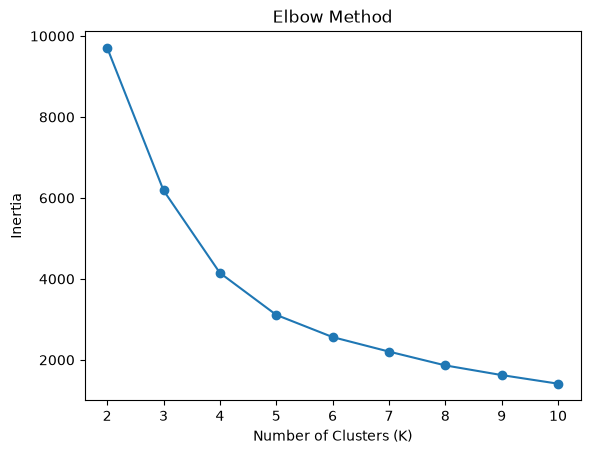

In [10]:
##Determine Optimal K
inertias = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.plot(range(2, 11), inertias, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [11]:
##Train K-Means
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df["Segment"] = kmeans.fit_predict(X_scaled)

In [12]:
##Analyze Segment Characteristics
segment_summary = df.groupby("Segment")[features].mean().round(2)

segment_summary

,tenure,MonthlyCharges,TotalCharges
Segment,,,
0,10.21,31.78,302.15
1,59.53,93.31,5548.65
2,15.42,80.78,1251.17
3,53.57,34.91,1835.62


In [13]:
##Analyze Churn Rate by Segment
churn_by_segment = pd.crosstab(
    df["Segment"],
    df["Churn"],
    normalize="index"
) * 100

churn_by_segment.round(2)

Churn,No,Yes
Segment,,
0,75.34,24.66
1,84.61,15.39
2,51.76,48.24
3,95.00,5.00


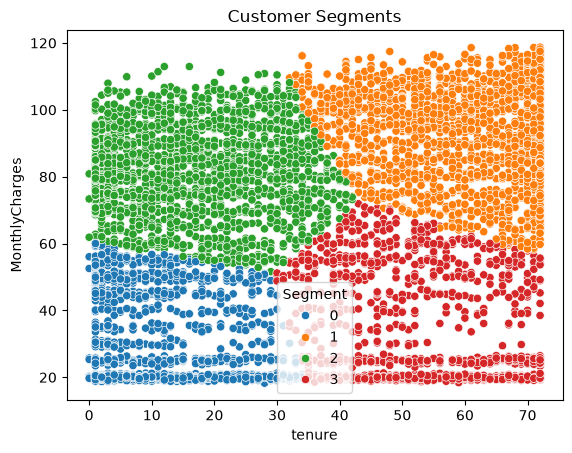

In [14]:
##Visualize Customer Segments
sns.scatterplot(
    data=df,
    x="tenure",
    y="MonthlyCharges",
    hue="Segment",
    palette="tab10"
)

plt.title("Customer Segments")
plt.show()